In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
import time
import matplotlib
import json

import matplotlib.pyplot as plt
from regex import F
import torch
import sounddevice as sd
from torch.export import Dim

from kokoro import KModel, KPipeline
from kokoro.model import KModelForONNX

import scipy.io.wavfile as wavfile

torch.set_num_threads(8)


2026-01-16 09:54:22.521828: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-16 09:54:22.581462: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
MAX_INPUT_LENGTH = 510

config_file = "checkpoints/config.json"
checkpoint_path = "checkpoints/kokoro-v1_0.pth"

kmodel = KModel(config=config_file, model=checkpoint_path, disable_complex=True).to('cpu')
model = KModelForONNX(kmodel).eval()

with open(config_file, 'r', encoding='utf-8') as r:
    config = json.load(r)

timings = {}
dbg=[]

/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [4]:
def load_input_ids(pipeline, text):
    if pipeline.lang_code in 'ab':
        _, tokens = pipeline.g2p(text)
        for gs, ps, tks in pipeline.en_tokenize(tokens):
            if not ps:
                continue
    else:
        ps, _ = pipeline.g2p(text)

    if len(ps) > 510:
        ps = ps[:510]

    input_ids = list(filter(lambda i: i is not None, map(lambda p: pipeline.model.vocab.get(p), ps)))
    print(f"text: {text} -> phonemes: {ps} -> input_ids: {input_ids}")
    input_ids = torch.LongTensor([[0, *input_ids, 0]]).to(pipeline.model.device)
    return ps, input_ids

def load_voice(pipeline, voice, phonemes):
    pack = pipeline.load_voice(voice).to('cpu')
    return pack[len(phonemes) - 1]

def load_sample(model):
    pipeline = KPipeline(lang_code='a', model=model.kmodel, device='cpu')
    text = '''
    In today's fast-paced tech world, building software applications has never been easier — thanks to AI-powered coding assistants.'
    '''
    text = '''
    The sky above the port was the color of television, tuned to a dead channel.
    '''

    text = "I had returned to civil practice and had finally abandoned Holmes in his Baker Street rooms, although I continually visited him and occasionally even persuaded him to forgo his Bohemian habits so far as to come and visit us."
    voice = 'checkpoints/voices/af_heart.pt'

    phonemes, input_ids = load_input_ids(pipeline, text)
    style = load_voice(pipeline, voice, phonemes)
    speed = torch.IntTensor([1])

    return input_ids, style, speed

In [5]:


class model_bert(torch.nn.Module):
    def __init__(self, model):
        super(model_bert, self).__init__()
        self.bert = model.bert
        self.bert_encoder = model.bert_encoder

    def forward(self, input_ids, text_mask):
        start = time.perf_counter()
        bert_dur = self.bert(input_ids, attention_mask=text_mask)
        timings['bert'] = time.perf_counter() - start
        
        start = time.perf_counter()
        d_en = self.bert_encoder(bert_dur).transpose(-1, -2)
        timings['bert_encoder'] = time.perf_counter() - start
        
        return d_en

class model_duration_predictor(torch.nn.Module):
    def __init__(self, model):
        super(model_duration_predictor, self).__init__()
        self.predictor = model.predictor
        self.text_encoder = model.text_encoder

    def forward(self, input_ids, d_en, style, text_mask, speed):
        start = time.perf_counter()
        d = self.predictor.text_encoder(d_en, style[:, 128:], text_mask)
        timings['predictor_text_encoder'] = time.perf_counter() - start
        
        start = time.perf_counter()
        x, _ = self.predictor.lstm(d)
        timings['predictor_lstm'] = time.perf_counter() - start

        start = time.perf_counter()
        duration = self.predictor.duration_proj(x)
        duration = text_mask * torch.sigmoid(duration).sum(axis=-1) / speed
        pred_dur = torch.round(duration).squeeze()
        timings['duration_proj'] = time.perf_counter() - start

        input_tensor = d.transpose(-1, -2)
        boundaries = torch.cumsum(pred_dur, dim=0)
        values = torch.arange(boundaries[-1])
        expanded_indices = torch.sum(boundaries.unsqueeze(1) <= values.unsqueeze(0), dim=0)
        
        start = time.perf_counter()
        en = torch.index_select(input_tensor, 2, expanded_indices)
        en, _ = self.predictor.shared(en.transpose(-1, -2))
        timings['predictor_shared'] = time.perf_counter() - start
        
        start = time.perf_counter()
        t_en = self.text_encoder(input_ids, text_mask)
        timings['text_encoder'] = time.perf_counter() - start
        
        asr = torch.index_select(t_en, 2, expanded_indices)

        return pred_dur, input_tensor, expanded_indices, en, asr

In [6]:
import math
import torch.nn.functional as F
from kokoro.istftnet import AdainResBlk1d, Generator, weight_norm, SourceModuleHnNSF, AdaINResBlock1, init_weights
import torch.nn as nn
from kokoro.custom_stft import CustomSTFT, TorchSTFT


class Generator(nn.Module):
    def __init__(self, style_dim, resblock_kernel_sizes, upsample_rates, upsample_initial_channel, resblock_dilation_sizes, upsample_kernel_sizes, gen_istft_n_fft, gen_istft_hop_size, disable_complex=False):
        super(Generator, self).__init__()
        self.num_kernels = len(resblock_kernel_sizes)
        self.num_upsamples = len(upsample_rates)
        self.m_source = SourceModuleHnNSF(
                    sampling_rate=24000,
                    upsample_scale=math.prod(upsample_rates) * gen_istft_hop_size,
                    harmonic_num=8, voiced_threshod=10)
        self.f0_upsamp = nn.Upsample(scale_factor=math.prod(upsample_rates) * gen_istft_hop_size)
        self.noise_convs = nn.ModuleList()
        self.noise_res = nn.ModuleList()
        self.ups = nn.ModuleList()
        for i, (u, k) in enumerate(zip(upsample_rates, upsample_kernel_sizes)):
            self.ups.append(weight_norm(
                nn.ConvTranspose1d(upsample_initial_channel//(2**i), upsample_initial_channel//(2**(i+1)),
                                   k, u, padding=(k-u)//2)))
        self.resblocks = nn.ModuleList()
        for i in range(len(self.ups)):
            ch = upsample_initial_channel//(2**(i+1))
            for j, (k, d) in enumerate(zip(resblock_kernel_sizes,resblock_dilation_sizes)):
                self.resblocks.append(AdaINResBlock1(ch, k, d, style_dim))
            c_cur = upsample_initial_channel // (2 ** (i + 1))
            if i + 1 < len(upsample_rates):
                stride_f0 = math.prod(upsample_rates[i + 1:])

                self.noise_convs.append(nn.Conv1d(
                    gen_istft_n_fft + 2, c_cur, kernel_size=stride_f0 * 2, stride=stride_f0, padding=(stride_f0+1) // 2))
                self.noise_res.append(AdaINResBlock1(c_cur, 7, [1,3,5], style_dim))
            else:
                self.noise_convs.append(nn.Conv1d(gen_istft_n_fft + 2, c_cur, kernel_size=1))
                self.noise_res.append(AdaINResBlock1(c_cur, 11, [1,3,5], style_dim))
        self.post_n_fft = gen_istft_n_fft
        self.conv_post = weight_norm(nn.Conv1d(ch, self.post_n_fft + 2, 7, 1, padding=3))
        self.ups.apply(init_weights)
        self.conv_post.apply(init_weights)
        self.reflection_pad = nn.ReflectionPad1d((1, 0))
        # self.stft = (
        #     CustomSTFT(filter_length=gen_istft_n_fft, hop_length=gen_istft_hop_size, win_length=gen_istft_n_fft)
        #     if disable_complex
        #     else TorchSTFT(filter_length=gen_istft_n_fft, hop_length=gen_istft_hop_size, win_length=gen_istft_n_fft)
        # )
        
        self.stft = TorchSTFT(filter_length=gen_istft_n_fft, hop_length=gen_istft_hop_size, win_length=gen_istft_n_fft)

    def forward(self, x, s, f0):
        start = time.perf_counter()
        with torch.no_grad():
            f0 = self.f0_upsamp(f0[:, None]).transpose(1, 2)  # bs,n,t
            har_source, noi_source, uv = self.m_source(f0)
            har_source = har_source.transpose(1, 2).squeeze(1)
            har_spec, har_phase = self.stft.transform(har_source)
            har = torch.cat([har_spec, har_phase], dim=1)
        timings['generator_source'] = time.perf_counter() - start

        print(f"\nGenerator: {x.shape=} {s.shape=} {har.shape=}, {har_spec.shape=}, {f0.shape=}")

        for i in range(self.num_upsamples):
            start = time.perf_counter()
            x = F.leaky_relu(x, negative_slope=0.1) 

            x_source = self.noise_convs[i](har)
            x_source = self.noise_res[i](x_source, s)
            x = self.ups[i](x)
            if i == self.num_upsamples - 1:
                x = self.reflection_pad(x)
                
            x = x + x_source
            xs = None
            print(f"\n  After upsample {i}: {x.shape=}")
            for j in range(self.num_kernels):
                if xs is None:
                    xs = self.resblocks[i*self.num_kernels+j](x, s)
                else:
                    xs = xs + self.resblocks[i*self.num_kernels+j](x, s)
                print(f"\t\t xs {i}_{j}: {xs.shape=}")

            x = xs / self.num_kernels
            print(f"\n    After resblocks {i}: {x.shape=}")
            timings[f'generator_pre_stft_{i}'] = time.perf_counter() - start
        x = F.leaky_relu(x)
        x = self.conv_post(x)

        print(f"\n  Before ISTFT: {x.shape=}")
        start = time.perf_counter()
        spec = torch.exp(x[:,:self.post_n_fft // 2 + 1, :])
        phase = torch.sin(x[:, self.post_n_fft // 2 + 1:, :])
        
        ret = self.stft.inverse(spec, phase)
        print(f"\n  Spec: {spec.shape=} {ret.shape=}")
        timings['generator_stft'] = time.perf_counter() - start
        return ret


class Decoder(nn.Module):
    def __init__(self, dim_in, style_dim, dim_out, 
                 resblock_kernel_sizes,
                 upsample_rates,
                 upsample_initial_channel,
                 resblock_dilation_sizes,
                 upsample_kernel_sizes,
                 gen_istft_n_fft, gen_istft_hop_size,
                 disable_complex=False):
        super().__init__()
        self.encode = AdainResBlk1d(dim_in + 2, 1024, style_dim)
        self.decode = nn.ModuleList()
        self.decode.append(AdainResBlk1d(1024 + 2 + 64, 1024, style_dim))
        self.decode.append(AdainResBlk1d(1024 + 2 + 64, 1024, style_dim))
        self.decode.append(AdainResBlk1d(1024 + 2 + 64, 1024, style_dim))
        self.decode.append(AdainResBlk1d(1024 + 2 + 64, 512, style_dim, upsample=True))
        self.F0_conv = weight_norm(nn.Conv1d(1, 1, kernel_size=3, stride=2, groups=1, padding=1))
        self.N_conv = weight_norm(nn.Conv1d(1, 1, kernel_size=3, stride=2, groups=1, padding=1))
        self.asr_res = nn.Sequential(weight_norm(nn.Conv1d(512, 64, kernel_size=1)))
        self.generator = Generator(style_dim, resblock_kernel_sizes, upsample_rates, 
                                   upsample_initial_channel, resblock_dilation_sizes, 
                                   upsample_kernel_sizes, gen_istft_n_fft, gen_istft_hop_size, disable_complex=disable_complex)

    def forward(self, asr, F0_curve, N, s):

        start = time.perf_counter()
        F0 = self.F0_conv(F0_curve.unsqueeze(1))
        N = self.N_conv(N.unsqueeze(1))
        
        x = torch.cat([asr, F0, N], axis=1)
        x = self.encode(x, s)
        
        asr_res = self.asr_res(asr)
        res = True
        for i, block in enumerate(self.decode):
            if res:
                # print(f"torch: Before cat: {x.shape=}, {asr_res.shape=}, {F0.shape=}, {N.shape=}")
                x = torch.cat([x, asr_res, F0, N], axis=1)
            x = block(x, s)
            # print(f"torch: After block: {block=} {x.shape=} {s.shape=}")
            if block.upsample_type != "none":
                res = False
        timings['F0_upsample'] = time.perf_counter()-start 

        dbg.append([x.clone(), s.clone(),F0_curve.clone()])
        start = time.perf_counter()
        x = self.generator(x, s, F0_curve)
        timings['generator'] = time.perf_counter() - start
        return x


In [7]:

class model_text_encoder(torch.nn.Module):
    def __init__(self, model):
        super(model_text_encoder, self).__init__()
        self.text_encoder = model.text_encoder
        self.predictor = model.predictor

        self.decoder = Decoder(
            dim_in=config['hidden_dim'], style_dim=config['style_dim'],
            dim_out=config['n_mels'], disable_complex=False, **config['istftnet']
        )
        self.decoder.load_state_dict(model.decoder.state_dict())
        self.decoder.generator.load_state_dict(model.decoder.generator.state_dict())

    def forward(self, en, style, asr):
        start = time.perf_counter()
        F0_pred, N_pred = self.predictor.F0Ntrain(en, style[:, 128:256])
        timings['F0Ntrain'] = time.perf_counter() - start
        
        # start = time.perf_counter()
        audio = self.decoder(asr, F0_pred, N_pred, style[:, 0:128]).squeeze()
        # timings['decoder'] = time.perf_counter() - start
        
        return audio, F0_pred, N_pred


In [8]:
input_ids, style, speed = load_sample(model)


text_mask = torch.zeros(1, MAX_INPUT_LENGTH, dtype=torch.float32).to(input_ids.device)
text_mask[0, :input_ids.shape[1]] = 1
input_ids = torch.nn.functional.pad(input_ids, (0, MAX_INPUT_LENGTH - input_ids.shape[1]))
# text_mask = (input_ids != 0).float()

with torch.no_grad():
    model_bert_instance = model_bert(model.kmodel).eval()
    d_en = model_bert_instance(input_ids, text_mask)

    model_duration_instance = model_duration_predictor(model.kmodel).eval()
    pred_dur, input_tensor, expanded_indices, en, asr = model_duration_instance(input_ids, d_en, style, text_mask, speed)

text: I had returned to civil practice and had finally abandoned Holmes in his Baker Street rooms, although I continually visited him and occasionally even persuaded him to forgo his Bohemian habits so far as to come and visit us. -> phonemes: ˌI hæd ɹətˈɜɹnd tə sˈɪvəl pɹˈæktəs ænd hæd fˈInᵊli əbˈændᵊnd hˈOmz ɪn hɪz bˈAkəɹ stɹˈit ɹˈumz, ɔlðˈO ˌI kəntˈɪnjʊəli vˈɪzɪTᵻd hˌɪm ænd əkˈAʒᵊnəli ˈivən pəɹswˈAdᵻd hˌɪm tə fɔɹɡˈO hɪz bOhˈimiən hˈæbəts sˌO fˈɑɹ æz tə kˈʌm ænd vˈɪzət ˌʌs. -> input_ids: [157, 25, 16, 50, 72, 46, 16, 123, 83, 62, 156, 87, 123, 56, 46, 16, 62, 83, 16, 61, 156, 102, 64, 83, 54, 16, 58, 123, 156, 72, 53, 62, 83, 61, 16, 72, 56, 46, 16, 50, 72, 46, 16, 48, 156, 25, 56, 42, 54, 51, 16, 83, 44, 156, 72, 56, 46, 42, 56, 46, 16, 50, 156, 31, 55, 68, 16, 102, 56, 16, 50, 102, 68, 16, 44, 156, 24, 53, 83, 123, 16, 61, 62, 123, 156, 51, 62, 16, 123, 156, 63, 55, 68, 3, 16, 76, 54, 81, 156, 31, 16, 157, 25, 16, 53, 83, 56, 62, 156, 102, 56, 52, 135, 83, 54, 51, 16, 64, 156, 102, 

In [9]:

model_text_encoder_instance = model_text_encoder(model.kmodel).eval()
audio, F0_pred, N_pred = model_text_encoder_instance(en, style, asr)
print(f"{audio.shape=} {F0_pred.shape=} {N_pred.shape=}")



Generator: x.shape=torch.Size([1, 512, 1084]) s.shape=torch.Size([1, 128]) har.shape=torch.Size([1, 22, 65041]), har_spec.shape=torch.Size([1, 11, 65041]), f0.shape=torch.Size([1, 325200, 1])

  After upsample 0: x.shape=torch.Size([1, 256, 10840])


		 xs 0_0: xs.shape=torch.Size([1, 256, 10840])
		 xs 0_1: xs.shape=torch.Size([1, 256, 10840])
		 xs 0_2: xs.shape=torch.Size([1, 256, 10840])

    After resblocks 0: x.shape=torch.Size([1, 256, 10840])

  After upsample 1: x.shape=torch.Size([1, 128, 65041])
		 xs 1_0: xs.shape=torch.Size([1, 128, 65041])
		 xs 1_1: xs.shape=torch.Size([1, 128, 65041])
		 xs 1_2: xs.shape=torch.Size([1, 128, 65041])

    After resblocks 1: x.shape=torch.Size([1, 128, 65041])

  Before ISTFT: x.shape=torch.Size([1, 22, 65041])

  Spec: spec.shape=torch.Size([1, 11, 65041]) ret.shape=torch.Size([1, 1, 325200])
audio.shape=torch.Size([325200]) F0_pred.shape=torch.Size([1, 1084]) N_pred.shape=torch.Size([1, 1084])


In [10]:
x, s,F0_curve=dbg[0]

In [11]:
class Generator_dev(nn.Module):
    def __init__(self, style_dim, resblock_kernel_sizes, upsample_rates, upsample_initial_channel, resblock_dilation_sizes, upsample_kernel_sizes, gen_istft_n_fft, gen_istft_hop_size, disable_complex=False):
        super(Generator_dev, self).__init__()
        self.num_kernels = len(resblock_kernel_sizes)
        self.num_upsamples = len(upsample_rates)
        self.m_source = SourceModuleHnNSF(
                    sampling_rate=24000,
                    upsample_scale=math.prod(upsample_rates) * gen_istft_hop_size,
                    harmonic_num=8, voiced_threshod=10)
        self.f0_upsamp = nn.Upsample(scale_factor=math.prod(upsample_rates) * gen_istft_hop_size)
        self.noise_convs = nn.ModuleList()
        self.noise_res = nn.ModuleList()
        self.ups = nn.ModuleList()
        for i, (u, k) in enumerate(zip(upsample_rates, upsample_kernel_sizes)):
            self.ups.append(weight_norm(
                nn.ConvTranspose1d(upsample_initial_channel//(2**i), upsample_initial_channel//(2**(i+1)),
                                   k, u, padding=(k-u)//2)))
        self.resblocks = nn.ModuleList()
        for i in range(len(self.ups)):
            ch = upsample_initial_channel//(2**(i+1))
            for j, (k, d) in enumerate(zip(resblock_kernel_sizes,resblock_dilation_sizes)):
                self.resblocks.append(AdaINResBlock1(ch, k, d, style_dim))
            c_cur = upsample_initial_channel // (2 ** (i + 1))
            if i + 1 < len(upsample_rates):
                stride_f0 = math.prod(upsample_rates[i + 1:])

                self.noise_convs.append(nn.Conv1d(
                    gen_istft_n_fft + 2, c_cur, kernel_size=stride_f0 * 2, stride=stride_f0, padding=(stride_f0+1) // 2))
                self.noise_res.append(AdaINResBlock1(c_cur, 7, [1,3,5], style_dim))
            else:
                self.noise_convs.append(nn.Conv1d(gen_istft_n_fft + 2, c_cur, kernel_size=1))
                self.noise_res.append(AdaINResBlock1(c_cur, 11, [1,3,5], style_dim))
        self.post_n_fft = gen_istft_n_fft
        self.conv_post = weight_norm(nn.Conv1d(ch, self.post_n_fft + 2, 7, 1, padding=3))
        self.ups.apply(init_weights)
        self.conv_post.apply(init_weights)
        self.reflection_pad = nn.ReflectionPad1d((1, 0))
        # self.stft = (
        #     CustomSTFT(filter_length=gen_istft_n_fft, hop_length=gen_istft_hop_size, win_length=gen_istft_n_fft)
        #     if disable_complex
        #     else TorchSTFT(filter_length=gen_istft_n_fft, hop_length=gen_istft_hop_size, win_length=gen_istft_n_fft)
        # )
        
        self.stft = TorchSTFT(filter_length=gen_istft_n_fft, hop_length=gen_istft_hop_size, win_length=gen_istft_n_fft)

    def upsample_f0(self, f0):
        with torch.no_grad():
            f0 = self.f0_upsamp(f0[:, None]).transpose(1, 2)  # bs,n,t
            har_source, noi_source, uv = self.m_source(f0)
            har_source = har_source.transpose(1, 2).squeeze(1)
            har_spec, har_phase = self.stft.transform(har_source)
            har = torch.cat([har_spec, har_phase], dim=1)
        return har
        
    def forward(self, x, s, f0):

        har = self.upsample_f0(f0)
        
        print(f"\nGenerator: {x.shape=} {s.shape=} {har.shape=} {f0.shape=}")
        with torch.no_grad():
            for i in range(self.num_upsamples):
                start = time.perf_counter()
                x = F.leaky_relu(x, negative_slope=0.1) 

                x_source = self.noise_convs[i](har)
                x_source = self.noise_res[i](x_source, s)
                x = self.ups[i](x)
                if i == self.num_upsamples - 1:
                    x = self.reflection_pad(x)
                    
                x = x + x_source
                xs = None
                for j in range(self.num_kernels):
                    if xs is None:
                        xs = self.resblocks[i*self.num_kernels+j](x, s)
                    else:
                        xs = xs + self.resblocks[i*self.num_kernels+j](x, s)
                    print(f"\t\t xs {i}_{j}: {xs.shape=}")

                x = xs / self.num_kernels
                print(f"\n    After resblocks {i}: {x.shape=}")
            x = F.leaky_relu(x)
            x = self.conv_post(x)

            print(f"\n  Before ISTFT: {x.shape=}")
            spec = torch.exp(x[:,:self.post_n_fft // 2 + 1, :])
            phase = torch.sin(x[:, self.post_n_fft // 2 + 1:, :])
            
            ret = self.stft.inverse(spec, phase)
            print(f"\n  Spec: {spec.shape=} {ret.shape=}")
        return ret, spec
    
    def streaming(self, x, s, f0, n1, n2):
        har = self.upsample_f0(f0)
        x = x[:,:,n1:n2]
        har = har[:,:,(60*n1):(60*n2+1)]
        
        for i in range(self.num_upsamples):
            start = time.perf_counter()
            x = F.leaky_relu(x, negative_slope=0.1) 

            x_source = self.noise_convs[i](har)
            x_source = self.noise_res[i](x_source, s)
            x = self.ups[i](x)
            if i == self.num_upsamples - 1:
                x = self.reflection_pad(x)
                
            x = x + x_source
            xs = None
            for j in range(self.num_kernels):
                if xs is None:
                    xs = self.resblocks[i*self.num_kernels+j](x, s)
                else:
                    xs = xs + self.resblocks[i*self.num_kernels+j](x, s)

            x = xs / self.num_kernels
        x = F.leaky_relu(x)
        x = self.conv_post(x)

        spec = torch.exp(x[:,:self.post_n_fft // 2 + 1, :])
        phase = torch.sin(x[:, self.post_n_fft // 2 + 1:, :])
        
        ret = self.stft.inverse(spec, phase)
        return ret, spec
   

generator = Generator_dev(style_dim=config['style_dim'],
            disable_complex=False, **config['istftnet'])
generator.load_state_dict(model.kmodel.decoder.generator.state_dict())

<All keys matched successfully>

In [12]:
list(range(0, 201, 20))

[0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]


Generator: x.shape=torch.Size([1, 512, 1084]) s.shape=torch.Size([1, 128]) har.shape=torch.Size([1, 22, 65041]) f0.shape=torch.Size([1, 1084])
		 xs 0_0: xs.shape=torch.Size([1, 256, 10840])
		 xs 0_1: xs.shape=torch.Size([1, 256, 10840])
		 xs 0_2: xs.shape=torch.Size([1, 256, 10840])

    After resblocks 0: x.shape=torch.Size([1, 256, 10840])
		 xs 1_0: xs.shape=torch.Size([1, 128, 65041])
		 xs 1_1: xs.shape=torch.Size([1, 128, 65041])
		 xs 1_2: xs.shape=torch.Size([1, 128, 65041])

    After resblocks 1: x.shape=torch.Size([1, 128, 65041])

  Before ISTFT: x.shape=torch.Size([1, 22, 65041])

  Spec: spec.shape=torch.Size([1, 11, 65041]) ret.shape=torch.Size([1, 1, 325200])


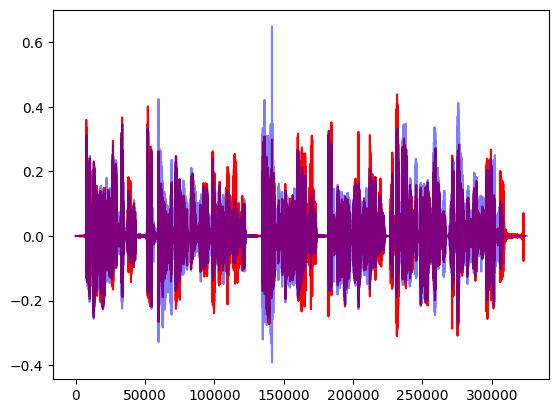

In [66]:
audio, spec = generator.forward(x, s, F0_curve)

nmax = x.shape[-1]+1
audio_ref, spec_ref = generator.streaming(x, s, F0_curve, 0, nmax)

# Streaming parameters
CHUNK_SIZE = 60
OVERLAP = 4
OVERLAP_TRIM = 300*OVERLAP

# plt.plot(audio[0,0,:].detach(),'b')
audios = []
specs = []

for chunk_start in range(0, nmax, CHUNK_SIZE):
    # Calculate chunk boundaries with overlap
    start_idx = max(0, chunk_start - OVERLAP)
    end_idx = min(nmax, chunk_start + CHUNK_SIZE + OVERLAP)
    
    # Generate audio for this chunk
    audio_chunk, spec_chunk = generator.streaming(x, s, F0_curve, start_idx, end_idx)
    
    # Trim overlap regions
    trim_start = OVERLAP_TRIM if chunk_start > 0 else 0
    trim_end = -OVERLAP_TRIM
    
    audios.append(audio_chunk[:, :, trim_start:trim_end])
    specs.append(spec_chunk[:, :, (trim_start//50):(trim_end//50)])

audio_s = torch.cat(audios, dim=-1)
spec_s = torch.cat(specs, dim=-1)






# audio_s1, spec_s1 = generator.streaming(x, s, F0_curve, 0, 61)
# audio_s2, spec_s2 = generator.streaming(x, s, F0_curve, 59, 121)
# print(f"{audio_s1.shape=}, {audio_s2.shape=}")
# audio_s = torch.cat([audio_s1[0,0,0:-300], audio_s2[0,0,300:-300]], dim=-1)
plt.plot(audio_s.squeeze().detach(),'r')
plt.plot(audio[0,0,:].detach(),'b',alpha=0.5)
# plt.xlim(audio_s.shape[-1]/2-2000, audio_s.shape[-1]/2+2000)
# # plt.xlim(audio_s.shape[2]/2-2000, audio_s.shape[2]/2+2000)
# print(f"{spec.shape=}, {spec_s1.shape=}")

# a = spec.detach()[0,:,0:6061]
# diff = spec_s1.detach()[0,:,:] - a
# # plt.plot(diff[0,:],'b')

# plt.plot(spec_s1.detach()[0,2,:],'r')
# plt.plot(a[2,:],'b')
# plt.xlim(5000, 6000)

In [72]:
spec.shape, spec_s.shape

(torch.Size([1, 11, 65041]), torch.Size([1, 11, 72811]))

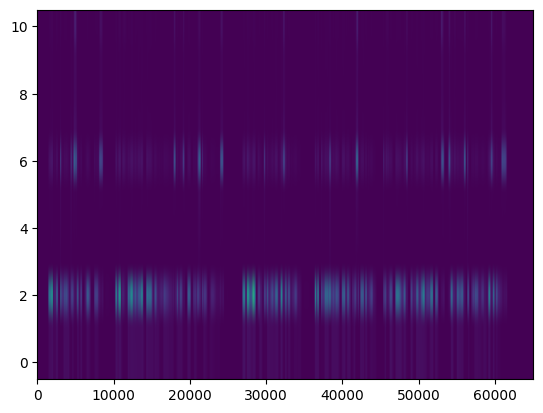

In [67]:
plt.imshow(spec[0,:,:].detach().cpu().numpy(), aspect='auto', origin='lower')

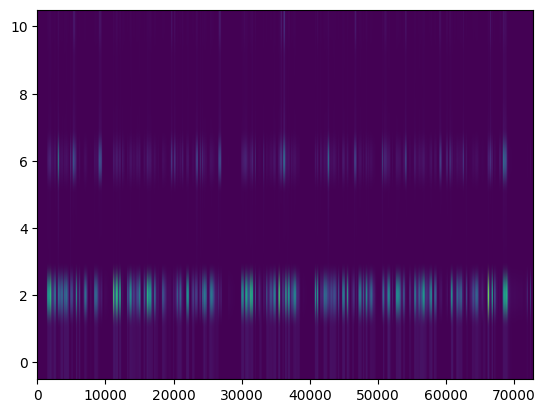

In [68]:
plt.imshow(spec_s[0,:,:].detach().cpu().numpy(), aspect='auto', origin='lower')

In [73]:
from IPython.display import Audio, display

display(Audio(audio_ref[0,0,:].detach().numpy(), rate=24000))

In [74]:
from IPython.display import Audio, display

display(Audio(audio_s[0,0,:].detach().numpy(), rate=24000))

-------------------------------------------------------------------------------------------

In [10]:
import pandas as pd

timings_df = pd.DataFrame(list(timings.items()), columns=['Component', 'Time (seconds)'])
timings_df['Time (ms)'] = timings_df['Time (seconds)'] * 1000
timings_df = timings_df.sort_values('Time (seconds)', ascending=False)
print(timings_df.to_string(index=False))

             Component  Time (seconds)   Time (ms)
             generator        2.133305 2133.305475
  generator_pre_stft_1        1.357495 1357.495017
  generator_pre_stft_0        0.633125  633.124754
                  bert        0.198070  198.069736
      generator_source        0.121963  121.963188
           F0_upsample        0.097379   97.379059
              F0Ntrain        0.038888   38.888127
predictor_text_encoder        0.028497   28.496653
          text_encoder        0.018833   18.832818
      predictor_shared        0.009687    9.687461
        predictor_lstm        0.007673    7.672966
        generator_stft        0.007571    7.570997
          bert_encoder        0.000949    0.949293
         duration_proj        0.000433    0.432849


In [9]:
import pandas as pd

timings_df = pd.DataFrame(list(timings.items()), columns=['Component', 'Time (seconds)'])
timings_df['Time (ms)'] = timings_df['Time (seconds)'] * 1000
timings_df = timings_df.sort_values('Time (seconds)', ascending=False)
print(timings_df.to_string(index=False))

             Component  Time (seconds)   Time (ms)
               decoder        1.463984 1463.983700
                  bert        0.127360  127.359547
predictor_text_encoder        0.083119   83.118595
              F0Ntrain        0.048628   48.628323
          text_encoder        0.039502   39.501525
      predictor_shared        0.026153   26.152894
        predictor_lstm        0.020825   20.825446
          bert_encoder        0.000531    0.530906
         duration_proj        0.000522    0.522129


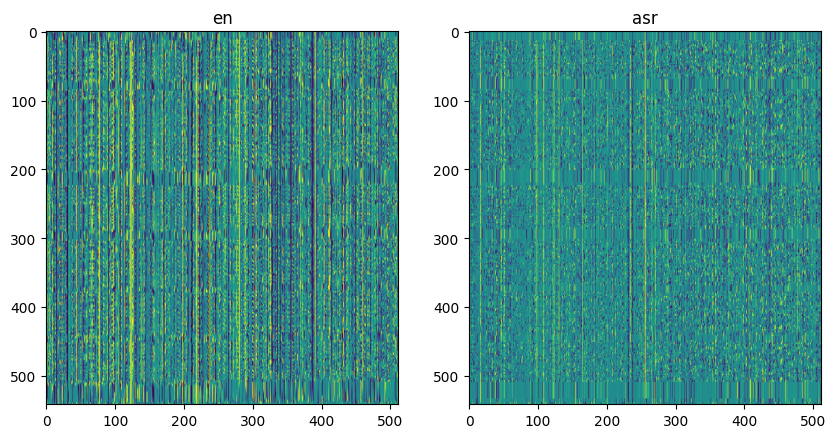

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(en[0,:,:])
axes[0].set_title('en')
axes[1].imshow(asr[0,:,:].T)
axes[1].set_title('asr')
plt.show()

In [11]:
print(f"{en.shape=} {asr.shape=}")

en.shape=torch.Size([1, 542, 512]) asr.shape=torch.Size([1, 512, 542])


audio.shape=torch.Size([325200]) F0_pred.shape=torch.Size([1, 1084]) N_pred.shape=torch.Size([1, 1084])
audio1.shape=torch.Size([12000]) F0_pred1.shape=torch.Size([1, 40]) N_pred1.shape=torch.Size([1, 40])
en.shape[1]/en[:,idx,:].shape[1]=27.1 audio.shape[0]/audio1.shape[0]=27.1 27.1=


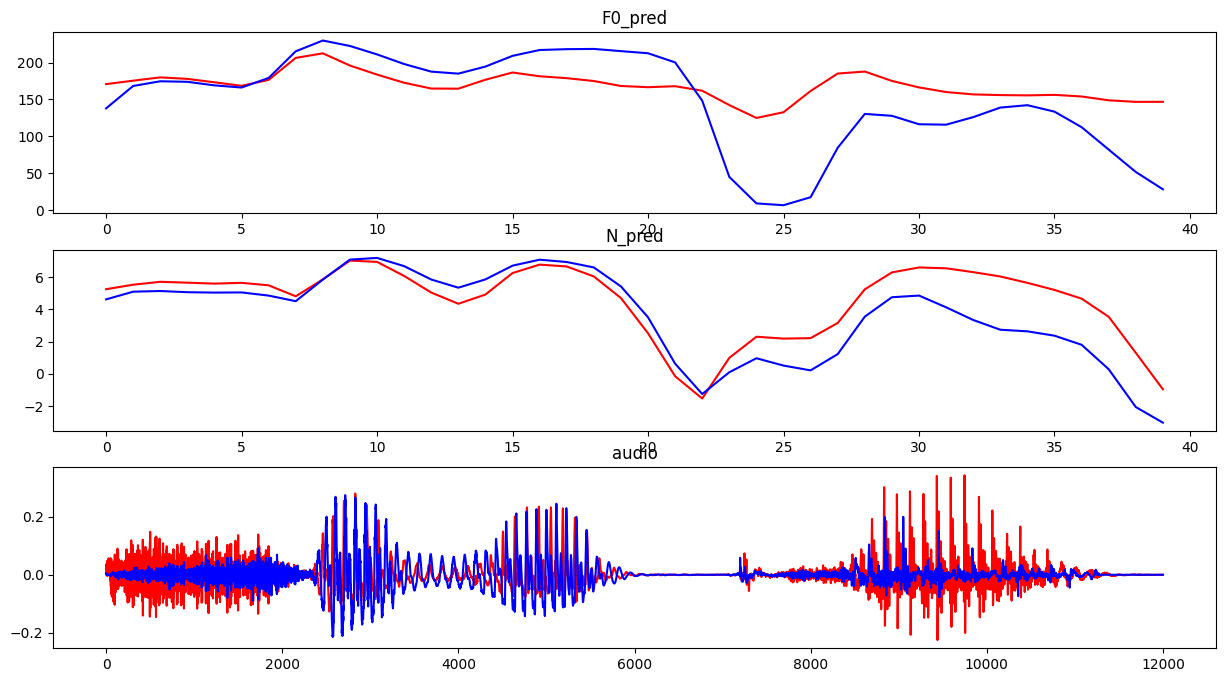

In [12]:
n1=40
n2=60

idx = slice(n1,n2)
idx2 = slice(2*n1,2*n2)
idxa = slice(n1*600, n2*600)

# audio1, F0_pred1, N_pred1 = model_text_encoder_instance(en[:,idx,:], style, asr[:,:,idx])

F0_pred1, N_pred1 = model_text_encoder_instance.predictor.F0Ntrain(en[:,idx,:], style[:, 128:256])
audio1 = model_text_encoder_instance.decoder(asr[:,:,idx], F0_pred1, N_pred1, style[:, 0:128]).squeeze()

print(f"{audio.shape=} {F0_pred.shape=} {N_pred.shape=}")
print(f"{audio1.shape=} {F0_pred1.shape=} {N_pred1.shape=}")
print(f"{en.shape[1]/en[:,idx,:].shape[1]=} {audio.shape[0]/audio1.shape[0]=} {F0_pred.shape[1]/F0_pred1.shape[1]}=")

fig, axes = plt.subplots(3, 1, figsize=(15, 8))
axes[0].plot(F0_pred.detach()[0,idx2],'r',F0_pred1.detach()[0,:],'b')
axes[0].set_title('F0_pred')
axes[1].plot(N_pred.detach()[0,idx2],'r',N_pred1.detach()[0,:],'b')
axes[1].set_title('N_pred')
axes[2].plot(audio.detach()[idxa],'r',audio1.detach()[:],'b')
axes[2].set_title('audio')
plt.show()


------------------------------------------------------------------------------------------------------------

In [13]:
style

tensor([[-0.2130,  0.1296, -0.0261, -0.1313, -0.3166,  0.0586, -0.0309, -0.1384,
         -0.2511, -0.1113,  0.0183, -0.0723,  0.2607,  0.1730,  0.2579, -0.2582,
         -0.1405, -0.0668,  0.0873, -0.2312, -0.1642, -0.1847,  0.0099,  0.1124,
         -0.0252,  0.0410, -0.2089,  0.1707,  0.0385, -0.0143,  0.0695, -0.0498,
         -0.0095, -0.0086, -0.1713,  0.1618, -0.1727, -0.2216,  0.1506,  0.1258,
         -0.0298,  0.0952, -0.0732,  0.0844, -0.1240, -0.1173,  0.0696,  0.1124,
         -0.0310,  0.0419,  0.1310,  0.0607,  0.1692,  0.3457, -0.0105,  0.2320,
          0.2215, -0.0733, -0.0244, -0.0388,  0.2789, -0.1468, -0.1692,  0.0358,
          0.0972,  0.0994,  0.0208,  0.0366,  0.0794, -0.1157,  0.0980,  0.0861,
          0.2078, -0.0792, -0.0613, -0.2007, -0.2428,  0.2133,  0.2407, -0.0703,
          0.1058,  0.0218, -0.1082,  0.2139,  0.1288,  0.0918,  0.0145, -0.1847,
         -0.2940, -0.1741,  0.2016, -0.0655, -0.0796,  0.0428, -0.1581, -0.1539,
          0.0347, -0.0417, -

slice(0, 60, None)


slice(40, 100, None)
slice(80, 140, None)
slice(120, 180, None)
slice(160, 220, None)
slice(200, 260, None)
slice(240, 300, None)
slice(280, 340, None)
slice(320, 380, None)
slice(360, 420, None)
slice(400, 460, None)
slice(440, 500, None)
slice(480, 540, None)
slice(520, 542, None)


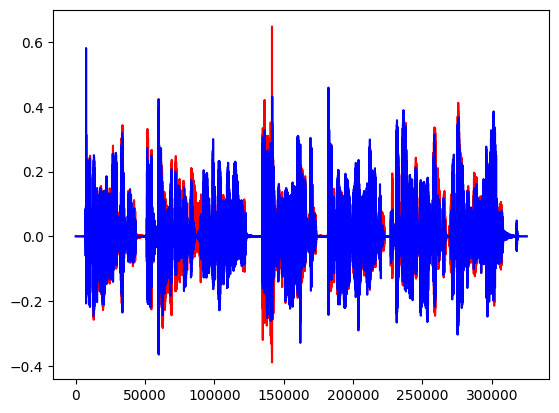

In [146]:
step = 40
width = 60
out_audio = torch.zeros_like(audio)


def _shift_with_padding(x, shift):
    if shift == 0:
        return x
    if shift > 0:
        pad = torch.zeros(shift, device=x.device, dtype=x.dtype)
        return torch.cat([pad, x[:-shift]])
    pad = torch.zeros(-shift, device=x.device, dtype=x.dtype)
    return torch.cat([x[-shift:], pad])


def _estimate_phase_shift(prev_seg, new_seg, max_shift=256):
    max_shift = min(max_shift, prev_seg.numel() - 1, new_seg.numel() - 1)
    if max_shift <= 0:
        return 0
    best_shift = 0
    best_score = None
    for shift in range(-max_shift, max_shift + 1):
        if shift < 0:
            a = prev_seg[-shift:]
            b = new_seg[:a.numel()]
        elif shift > 0:
            a = prev_seg[:-shift]
            b = new_seg[shift:]
        else:
            a = prev_seg
            b = new_seg
        score = torch.sum(a * b)
        if best_score is None or score > best_score:
            best_score = score
            best_shift = shift
    return best_shift


prev_end = 0
for i in range(0, en.shape[1], step):
    n1 = i
    n2 = min(i + width, en.shape[1])
    if n1 >= n2 - 4:
        break
    idx = slice(n1, n2)
    print(idx)
    idx2 = slice(2 * n1, 2 * n2)
    idxa = slice(n1 * 600, n2 * 600)

    # audio1, F0_pred1, N_pred1 = model_text_encoder_instance(en[:,idx,:], style, asr[:,:,idx])

    F0_pred1, N_pred1 = model_text_encoder_instance.predictor.F0Ntrain(en[:, idx, :], style[:, 128:256])
    audio1 = model_text_encoder_instance.decoder(asr[:, :, idx], F0_pred1, N_pred1, style[:, 0:128]).squeeze()

    if prev_end <= idxa.start:
        out_audio[idxa] = audio1
    else:
        overlap = min(prev_end - idxa.start, audio1.numel())
        if overlap <= 1:
            out_audio[idxa] = out_audio[idxa] + audio1
        else:
            prev_seg = out_audio[idxa.start:idxa.start + overlap].clone()
            new_seg = audio1[:overlap].clone()
            shift = _estimate_phase_shift(prev_seg, new_seg, max_shift=min(256, overlap // 2))
            aligned = _shift_with_padding(audio1, shift)
            fade = 0.5 - 0.5 * torch.cos(
                torch.linspace(0, torch.pi, overlap, device=out_audio.device, dtype=out_audio.dtype)
            )
            out_audio[idxa.start:idxa.start + overlap] = prev_seg * (1 - fade) + aligned[:overlap] * fade
            out_audio[idxa.start + overlap:idxa.stop] = aligned[overlap:idxa.stop - idxa.start]

    prev_end = max(prev_end, idxa.stop)


out_audio = out_audio.detach().numpy()
wavfile.write('stream_test.wav', 24000, (out_audio * 32767).astype('int16'))

plt.plot(audio.detach(), 'r', out_audio[:], 'b')
plt.show()

# print(f"{audio.shape=} {F0_pred.shape=} {N_pred.shape=}")
# print(f"{audio1.shape=} {F0_pred1.shape=} {N_pred1.shape=}")
# print(f"{en.shape[1]/en[:,idx,:].shape[1]=} {audio.shape[0]/audio1.shape[0]=} {F0_pred.shape[1]/F0_pred1.shape[1]}=")

# fig, axes = plt.subplots(3, 1, figsize=(15, 8))
# axes[0].plot(F0_pred.detach()[0,idx2],'r',F0_pred1.detach()[0,:],'b')
# axes[0].set_title('F0_pred')
# axes[1].plot(N_pred.detach()[0,idx2],'r',N_pred1.detach()[0,:],'b')
# axes[1].set_title('N_pred')
# axes[2].plot(audio.detach()[idxa],'r',audio1.detach()[:],'b')
# axes[2].set_title('audio')
# plt.show()
